
### HMM-HDP algorithm

In [ ]:
## utils.py
## The HMM-HDP method in RIPE Atlas is now deprecated. Use the HDPHMM.jl package instead.
import datetime as dt

import numpy as np
import pandas as pd
import pytz


def to_dataframe(obj, skip_na=True):
    df = pd.DataFrame.from_records(obj["results"], columns=obj["metadata"]["schema"])
    df["dt"] = df.timestamp.apply(lambda x: dt.datetime.fromtimestamp(x, pytz.UTC))
    df.loc[df.status != 0, "rtt"] = np.nan
    df.set_index("dt", inplace=True)
    if skip_na:
        df = df[df.rtt.first_valid_index() :]
    return df


def get_segments(df):
    segments = []
    last_idx, last_state = 0, df.state[0]
    for i in range(1, len(df.state)):
        if (df.state[i] != df.state[i - 1]) or (i == len(df.state) - 1):
            segments.append({"start": last_idx, "stop": i, "state": last_state})
            last_idx, last_state = i, df.state[i]
    return segments


def compute_transition_matrix(seq):
    mapping = {x[1]: x[0] for x in enumerate(sorted(np.unique(seq)))}
    transmat = np.zeros((len(mapping), len(mapping)))
    for i in range(len(seq) - 1):
        transmat[mapping[seq[i]], mapping[seq[i + 1]]] += 1
    transmat = transmat / np.sum(transmat, axis=1)[:, np.newaxis]
    return mapping, transmat


def utc_datetime(*args):
    return dt.datetime(*args, tzinfo=pytz.UTC)


def td_format(td_object):
    """
    Python format timedelta to string
    https://stackoverflow.com/a/13756038
    """
    seconds = int(td_object.total_seconds())
    return seconds
    # periods = [
    #     ('year',        60*60*24*365),
    #     ('month',       60*60*24*30),
    #     ('day',         60*60*24),
    #     ('hour',        60*60),
    #     ('minute',      60),
    #     # ('second',      1)
    # ]

    # strings = []
    # for period_name, period_seconds in periods:
    #     if seconds > period_seconds:
    #         period_value, seconds = divmod(seconds, period_seconds)
    #         has_s = 's' if period_value > 1 else ''
    #         strings.append("%s %s%s" % (period_value, period_name, has_s))

    # return ", ".join(strings)


In [ ]:
## plot.py

import datetime as dt
import math
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pytz
import seaborn as sns
from matplotlib.dates import DateFormatter, HourLocator
from pandas.plotting import register_matplotlib_converters
from scipy.stats import gaussian_kde

# from .utils import *

register_matplotlib_converters()


def set_mpl_style(font_size=12):
    # Old seaborn versions (such as the one in Google Colab)
    # modify the default matplotlib style on import.
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        sns.reset_orig()

    plt.rc("figure", figsize=(18, 2.5))
    plt.rc("font", size=font_size)
    plt.rc("axes", titlesize=font_size)
    plt.rc("text", usetex=False)
    plt.rc("font", family="sans-serif")
    plt.rc("legend", frameon=False)


def plot_trends(df, legend=True, ax=None):
    if ax is None:
        ax = plt.gca()
    if "rtt" in df:
        plot_rtt(df, ax=ax)
    if "state" in df:
        plot_state(df, ax=ax)
    if legend:
        add_legend(df, ax=ax)


def plot_rtt(df, ax=None):
    if ax is None:
        ax = plt.gca()
    ax.plot(df.index, df.rtt, drawstyle="steps-mid", lw=1)
    ax.set_xlim(df.index.min(), df.index.max() + dt.timedelta(minutes=4))
    ax.set_ylabel("RTT (ms)")
    ax.xaxis.set_major_locator(HourLocator(byhour=0, tz=pytz.UTC))
    ax.xaxis.set_major_formatter(DateFormatter("%d %b", tz=pytz.UTC))


def plot_state(df, ax=None):
    if ax is None:
        ax = plt.gca()
    palette = sns.husl_palette(df.state.max(), l=0.7, s=0.9)
    for segment in get_segments(df):
        start_dt = df.index[segment["start"]]
        stop_dt = df.index[segment["stop"]]
        color = palette[segment["state"] - 1]
        ax.axvspan(start_dt, stop_dt, alpha=0.3, color=color)


def add_legend(df, ax=None):
    if ax is None:
        ax = plt.gca()

    Δt = (df.index[1:] - df.index[:-1]).mean() / np.timedelta64(1, "s")
    mapping, transmat = compute_transition_matrix(df.state)

    palette = sns.husl_palette(df.state.max(), l=0.7, s=0.9)
    artists, labels = [], []

    for state in sorted(df.state.unique()):
        # Ignore division by zero (handled later)
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            avg_duration = (1 / (1 - transmat[mapping[state], mapping[state]])) * Δt

        if avg_duration == math.inf:
            avg_duration_str = "∞"
        else:
            avg_duration_str = td_format(dt.timedelta(seconds=avg_duration))

        # print(avg_duration_str)

        artists.append(plt.Rectangle((0, 0), 1, 1, color=palette[state - 1], alpha=0.6))
        # labels.append('State {}\nAvg. duration\n{}'.format(
        #     state, avg_duration_str))
        labels.append("{}".format(avg_duration_str))

    # print("new line")
    print(labels)

    # ax.legend(artists, labels, bbox_to_anchor=(
    #     0.5, -0.35), ncol=len(artists), loc='center')


def plot_kde(df, states=None):
    if states is None:
        states = df.state.unique()

    xmin, xmax = df.rtt.min(), df.rtt.max()
    X = np.arange(xmin - 10, xmax + 10, 0.1)
    palette = sns.husl_palette(df.state.max(), l=0.7, s=0.9)

    for state in sorted(states):
        obs = df[df.state == state].rtt.dropna()
        if len(obs) < 1:
            continue
        w = len(obs) / len(df.rtt.dropna())
        pdf = w * gaussian_kde(obs)(X)
        plt.plot(X, pdf, color=palette[state - 1])
        plt.fill_between(
            X, pdf, color=palette[state - 1], alpha=0.2, label="State {}".format(state)
        )

    ax = plt.gca()
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    plt.xlim(min(X), max(X))
    plt.xlabel("RTT (ms)")
    plt.ylabel("Density estimation")
    plt.legend(frameon=0)


In [ ]:
## clients.py

import datetime as dt
import math
import time

import requests

# from .utils import to_dataframe


class AtlasTrendsQuery:
    def __init__(
        self, resource, msm_id, prb_id, start_dt=None, stop_dt=None, subresource=None
    ):
        self.resource = resource
        self.subresource = subresource
        self.msm_id = msm_id
        self.prb_id = prb_id

        if stop_dt is None:
            stop_dt = dt.datetime.now()

        if start_dt is None:
            start_dt = stop_dt - dt.timedelta(days=7)

        self.start_dt = start_dt
        self.stop_dt = stop_dt

    def path(self):
        p = "/{}/{}/{}".format(self.resource, self.msm_id, self.prb_id)
        if self.subresource != None:
            p = p + "/{}".format(self.subresource)
        return p

    def params(self):
        return {
            "start": int(self.start_dt.timestamp()),
            "stop": int(self.stop_dt.timestamp()),
        }

    def estimated_time(self):
        """
        Heuristic for estimating the response time of a query, in seconds.
        """
        if self.resource == "ticks":
            k = 3150
        else:
            k = 450
        interval = dt.timedelta(minutes=4)
        t = 1 + (((self.stop_dt - self.start_dt) / interval) / k)
        return round(t, 1)


class AtlasTrendsClient:
    """
    Client for the RIPE Atlas Trends API.
    """

    DEFAULT_URL = "https://trends.atlas.ripe.net/api/v1"

    self = dict()

    def __init__(self, base_url=None, verbose=False):
        if base_url:
            self.base_url = base_url
        else:
            self.base_url = self.DEFAULT_URL
        self.verbose = verbose

    def get2(self, query):
        """
        API Errors are raised as Python exceptions.
        """
        # if self.verbose:
        # print('Estimated query time: {}s'.format(query.estimated_time()))
        wall_time = time.time()
        res = requests.get(self.base_url + query.path(), params=query.params())
        query_time = time.time() - wall_time
        # if self.verbose:
        # print('Actual query time: {}s'.format(round(query_time, 1)))
        obj = res.json()
        if res.status_code != 200:
            raise ValueError(obj["message"])
        return obj

    def fetch_ticks(self, msm_id, prb_id, start_dt=None, stop_dt=None, as_df=False):
        query = AtlasTrendsQuery("ticks", msm_id, prb_id, start_dt, stop_dt)
        res = self.get2(query)
        if as_df:
            return to_dataframe(res)
        else:
            return res

    def fetch_trends(self, msm_id, prb_id, start_dt=None, stop_dt=None, as_df=False):
        query = AtlasTrendsQuery("trends", msm_id, prb_id, start_dt, stop_dt)
        res = self.get2(query)
        if as_df:
            df2 = to_dataframe(res)
            add_legend(df2)
        else:
            df2 = res
            add_legend(df2)

    def fetch_summary(self, msm_id, prb_id, start_dt=None, stop_dt=None):
        query = AtlasTrendsQuery("trends", msm_id, prb_id, start_dt, stop_dt, "summary")
        return self.get2(query)


In [ ]:
client = AtlasTrendsClient(verbose=True)


In [ ]:
import pandas as pd
import numpy as np

probes_data = pd.read_csv("<PROBES_DATA_CSV_PATH>")


FileNotFoundError: [Errno 2] No such file or directory: './probes_data.csv'

In [ ]:
probes_data.head(5)


,probeid,fqdn,v4measid,v6measid
0,6030,rs-beg-as13004.anchors.atlas.ripe.net,1402085,1402087
1,6039,hu-bud-as12303.anchors.atlas.ripe.net,1423187,1423189
2,6041,is-rey-as25509.anchors.atlas.ripe.net,1425315,1425317
3,6042,at-vie-as1120.anchors.atlas.ripe.net,1437285,1437287
4,6043,fr-prm-as513.anchors.atlas.ripe.net,1442071,1442073


In [ ]:
probes = []
measurements = []

for index, row in probes_data.iterrows():
    probes.append(row["probeid"])
    measurements.append(row["v4measid"])

print(len(probes))
print(len(measurements))


124
124


measurement id: 1402085 probe id:6039
['840', '41520', '154240', '640', '210560', '23760', '240']
measurement id: 1402085 probe id:6041
['273359', '315719', '1559', '23759', '239']
measurement id: 1402085 probe id:6042
['3600', '2520', '161881', '547924', '240']
measurement id: 1423187 probe id:6030
['960', '83520', '463680', '157740', '12480', '240']
measurement id: 1423187 probe id:6041
['653520', '179520', '6600']
measurement id: 1423187 probe id:6042
['1201436', '3839']
measurement id: 1425315 probe id:6030
['182241', '157681', '1200', '11880', '240']
measurement id: 1425315 probe id:6039
['653521', '108864', '1920']
measurement id: 1425315 probe id:6042
['300', '168721', '274321', '8520', '148704', '360']
measurement id: 1437285 probe id:6030
['3360', '128785', '4080', '548164', '2520', '320']
measurement id: 1437285 probe id:6039
['1201671', '3839']
measurement id: 1437285 probe id:6041
['168719', '372359', '274319', '16559', '479', '359']


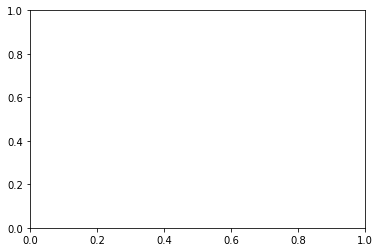

In [ ]:
for i in range(4):
    for j in range(4):
        if i != j:
            print("measurement id: {} probe id:{}".format(measurements[i], probes[j]))

            client.fetch_trends(
                msm_id=measurements[i],  # Atlas measurement ID
                prb_id=probes[j],  # Atlas probe ID
                start_dt=utc_datetime(
                    2020, 1, 1
                ),  # (Optional) Default: stop date - 7 days
                stop_dt=utc_datetime(
                    2020, 1, 15
                ),  # (Optional) Default: the current date
                as_df=True,  # (Optional) Returns a Pandas DataFrame instead of a JSON object
            )


In [ ]:
# client.fetch_trends(msm_id = 1423187, prb_id = 6030, start_dt = utc_datetime(2020, 1, 1), stop_dt = utc_datetime(2020, 1, 15), as_df = True)


##Bootstrap method

In [ ]:
import sys
import pandas as pd
import numpy as np


def find_cp(origarr):
    """
    Find change point location using min index of MSE.
    """
    avg = np.average(origarr)
    li = []
    for i in range(len(origarr) - 1):
        h1 = origarr[:i]
        h1 = np.add(h1, avg)
        h1 = np.square(h1)

        h2 = origarr[(i + 1) :]
        h2 = np.add(h2, avg)
        h2 = np.square(h2)
        s = np.sum(h1) + np.sum(h2)
        li.append(s)
    return np.argmin(li)


def cp_bootstrap_once(origarr, rounds=1000, thresh=95):
    """
    Compute whether change has occurred in origarr using bootstrap method.
    """
    if len(origarr) <= 1:
        return -1

    avg = np.average(origarr)

    def mkavgdiff(avg):
        def avgdiff(x):
            return x - avg

        return avgdiff

    avgdiff = np.frompyfunc(mkavgdiff(avg), 1, 1)

    def sdiff(arr):
        return max(arr) - min(arr)

    cusum = np.cumsum(avgdiff(origarr))
    sd = sdiff(cusum)
    # print("S_diff orig", sd)

    x = 0
    for _ in range(rounds):
        bootstrap = origarr.copy()
        np.random.shuffle(bootstrap)
        bootstrap_sd = sdiff(np.cumsum(avgdiff(bootstrap)))
        if bootstrap_sd < sd:
            x += 1
    conf = 100 * (x / rounds)
    # print(conf)
    if conf > thresh:
        cp = find_cp(origarr)
        return cp

    return -1


def _cp_bootstrap(origarr, rounds=1000, thresh=95, idx_offset=0):
    """
    Perform a "full" changepoint detection on a numpy array of values.
    Returns a list of indices of change points.
    """
    cp = cp_bootstrap_once(origarr, rounds, thresh)
    if cp > -1:
        # print("Change point found", cp+idx_offset)
        s1 = origarr[: (cp + 1)]
        a1 = _cp_bootstrap(s1, rounds, thresh, idx_offset)
        s2 = origarr[(cp + 1) :]
        a2 = _cp_bootstrap(s2, rounds, thresh, idx_offset + cp + 1)
        return sorted([cp + idx_offset] + a1 + a2)
    return []


def backwards_elimination(origarr, changepoints):
    """
    Performs backwards elimination to filter out irrelevant changepoints.
    """
    changepoints = [0] + changepoints + [len(origarr)]
    cps = []
    for i in range(1, len(changepoints) - 1):
        idx1 = changepoints[i - 1] + 1
        cp = changepoints[i]
        idx2 = changepoints[i + 1]

        # print("back", idx1, cp, idx2)
        iscp = _cp_bootstrap(origarr[idx1:idx2], idx_offset=idx1)
        if len(iscp):
            cps.append(cp)
        # else:
        #    print(cp, "eliminated")
    # print(len(changepoints), len(cps))
    return cps


def cp_bootstrap(arr):
    arr = np.array(arr)
    cps = _cp_bootstrap(arr)
    cps = backwards_elimination(arr, cps)
    return cps


if __name__ == "__main__":
    df = pd.read_json(sys.argv[1])
    arr = df["min"].values

    cps = cp_bootstrap(arr)
    print(cps)
    if cps == []:
        open(sys.argv[2], "w").close()
        exit()

    with open(sys.argv[2], "w") as outfile:
        prev = cps[0] - 1
        for i in range(len(cps)):
            this = cps[i]
            if this != prev:
                print(this, file=outfile)
            prev = this


FileNotFoundError: File --f=/home/aditya/.local/share/jupyter/runtime/kernel-v2-9664czVI3s448rIb.json does not exist

##Change point- Ranks method

In [ ]:
import sys
import pandas as pd
import numpy as np
import math
from scipy.stats import norm


def get_ranks(arr):
    """
    Replaces each value in a list with its rank (1 for smallest, n for biggest).
    """
    s = np.sort(arr)
    for i in range(len(s)):
        arr[np.where(arr == s[i])[0]] = i + 1
    return arr


def find_cp(origarr):
    """
    Find change point location using min index of MSE.
    """
    avg = np.average(origarr)
    li = []
    for i in range(len(origarr) - 1):
        h1 = origarr[:i]
        h1 = np.add(h1, avg)
        h1 = np.square(h1)

        h2 = origarr[(i + 1) :]
        h2 = np.add(h2, avg)
        h2 = np.square(h2)
        s = np.sum(h1) + np.sum(h2)
        li.append(s)
    return np.argmin(li)


def cp_ranks_once(origarr, rounds=1000, thresh=95):
    """
    Compute whether change has occurred in origarr using ranks method.
    """
    # Filter for empty arrays:
    if len(origarr) > 1:
        cp = find_cp(origarr.copy())
    else:
        return -1

    # faulty/no data:
    if origarr[cp] == -1:
        return -1

    # To prevent division by zero:
    # (removed in backwards_elimination if insignificant enough)
    # changepoint at right end of interval
    if cp == len(origarr) - 2:
        return cp_ranks_once(origarr[:-1])
    # changepoint at left end of interval
    if cp == 0:
        return cp_ranks_once(origarr[1:])

    s1 = origarr[:(cp)]
    x_minus = get_ranks(s1.copy())
    s2 = origarr[(cp + 1) :]
    x_plus = get_ranks(s2.copy())
    s12 = np.concatenate((s1, s2))
    x_union = get_ranks(s12.copy())

    r_minus = np.subtract(x_union[:(cp)], x_minus)
    r_plus = np.subtract(x_union[(cp):], x_plus)
    rp_mean = np.mean(r_plus)
    rm_mean = np.mean(r_minus)
    v_plus = np.sum((r_plus.copy() - rp_mean) ** 2)
    v_minus = np.sum((r_minus.copy() - rm_mean) ** 2)

    z = len(r_plus) * rp_mean - len(r_minus) * rm_mean
    z /= 2 * math.sqrt(rp_mean * rm_mean + v_plus + v_minus)
    cdf = norm.cdf(abs(z))
    l = (100 - thresh) / 100

    # Rejecting the null hypothesis:
    if cdf >= 1 - (l / 2):
        return cp
    return -1


def _cp_ranks(origarr, rounds=1000, thresh=95, idx_offset=0):
    """
    Perform a "full" changepoint detection on a numpy array of values.
    Returns a list of indices of change points.
    """
    cp = cp_ranks_once(origarr, rounds, thresh)
    if cp > -1:
        # print("Change point found", cp+idx_offset)
        s1 = origarr[: (cp + 1)]
        a1 = _cp_ranks(s1, rounds, thresh, idx_offset)
        s2 = origarr[(cp + 1) :]
        a2 = _cp_ranks(s2, rounds, thresh, idx_offset + cp + 1)
        return sorted([cp + idx_offset] + a1 + a2)
    return []


def backwards_elimination(origarr, changepoints):
    """
    Performs backwards elimination to filter out irrelevant changepoints.
    """
    changepoints = [0] + changepoints + [len(origarr)]
    cps = []
    for i in range(1, len(changepoints) - 1):
        idx1 = changepoints[i - 1] + 1
        cp = changepoints[i]
        idx2 = changepoints[i + 1]

        # print("back", idx1, cp, idx2)
        iscp = _cp_ranks(origarr[idx1:idx2], idx_offset=idx1)
        if len(iscp):
            cps.append(cp)
        # else:
        #    print(cp, "eliminated")
    # print(len(changepoints), len(cps))
    return cps


def cp_ranks(arr):
    arr = np.array(arr)
    cps = _cp_ranks(arr)
    cps = backwards_elimination(arr, cps)
    return cps


if __name__ == "__main__":
    df = pd.read_json(sys.argv[1])
    arr = df["min"].values

    cps = cp_ranks(arr)

    print(cps)
    if cps == []:
        open(sys.argv[2], "w").close()
        exit()

    with open(sys.argv[2], "w") as outfile:
        prev = cps[0] - 1
        for i in range(len(cps)):
            this = cps[i]
            if this != prev:
                print(this, file=outfile)
            prev = this
